# Visibility Models

This tutorial explains how `BinaryModelCartesian` and `BinaryModelAngular` work internally, how they interact with `OIData`, and how likelihoods are built from an `OIData` instance plus a model class.

## Introduce the visibility model parameterizations

We first define the Cartesian and angular binary models on the same baseline geometry, and verify they produce equivalent complex visibilities when parameters are converted consistently.

In [9]:
import sys
from pathlib import Path

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from drpangloss.models import (
    OIData,
    BinaryModelCartesian,
    BinaryModelAngular,
    loglike,
)

## Generate OIData from models

Now we generate synthetic observables from the Cartesian model and package them into an `OIData` instance.

These models are *parametrized functions* that take a set of parameters like sep, theta, contrast, and instantiate an object - say, `model` - which can then apply these to data. You then call `model.movel(u, v, wavel)` and it evaluates the complex visibilities at those coordinates.

In [10]:
rng = np.random.default_rng(21)
u = jnp.array(rng.uniform(-30.0, 30.0, size=24))
v = jnp.array(rng.uniform(-30.0, 30.0, size=24))
wavel = jnp.array([4.8e-6])

truth_cart = {"dra": 120.0, "ddec": -80.0, "flux": 4e-3}
model_cart_true = BinaryModelCartesian(**truth_cart)

dra = float(truth_cart["dra"])
ddec = float(truth_cart["ddec"])
flux = float(truth_cart["flux"])
sep = float(np.sqrt(dra**2 + ddec**2))
pa = float((np.degrees(np.arctan2(-dra, ddec)) + 360.0) % 360.0)
contrast = float(1.0 / flux)
model_ang = BinaryModelAngular(sep=sep, pa=pa, contrast=contrast)

cvis_true = model_cart_true.model(u, v, wavel)
cvis_ang = model_ang.model(u, v, wavel)
max_complex_diff = float(np.max(np.abs(np.asarray(cvis_ang - cvis_true))))

{
    "cartesian": truth_cart,
    "angular": {"sep": sep, "pa": pa, "contrast": contrast},
    "max_complex_visibility_difference": max_complex_diff,
}

{'cartesian': {'dra': 120.0, 'ddec': -80.0, 'flux': 0.004},
 'angular': {'sep': 144.22205101855957,
  'pa': 236.30993247402023,
  'contrast': 250.0},
 'max_complex_visibility_difference': 6.009040731669302e-08}

`OIData` stores observables, uncertainties, and convention flags (`v2_flag` and `cp_flag`) so model outputs can be converted and flattened consistently. It flattens all these data into vectors and keeps track of what kind of observable is being used.

In [11]:
vis_true = jnp.abs(cvis_true) ** 2
phi_true = jnp.rad2deg(jnp.angle(cvis_true))

d_vis = 0.002 * jnp.maximum(jnp.median(vis_true), 1e-6) * jnp.ones_like(vis_true)
d_phi = 0.01 * jnp.maximum(jnp.median(jnp.abs(phi_true)), 5.0) * jnp.ones_like(phi_true)

vis_obs = vis_true + d_vis * jnp.array(rng.normal(size=vis_true.shape))
phi_obs = phi_true + d_phi * jnp.array(rng.normal(size=phi_true.shape))

data = OIData({
    "u": u,
    "v": v,
    "wavel": wavel,
    "vis": vis_obs,
    "d_vis": d_vis,
    "phi": phi_obs,
    "d_phi": d_phi,
    "i_cps1": None,
    "i_cps2": None,
    "i_cps3": None,
    "v2_flag": True,
    "cp_flag": False,
})

{
    "n_baselines": int(data.u.shape[0]),
    "v2_flag": bool(data.v2_flag),
    "cp_flag": bool(data.cp_flag),
}

{'n_baselines': 24, 'v2_flag': True, 'cp_flag': False}

## How `OIData.model(...)` builds comparable vectors

`OIData.model(model_object)` evaluates complex visibilities through the model and converts them to the configured observables (`V²` and phases here), then flattens to match `OIData.flatten_data()`.

In [12]:
model_vector = data.model(model_cart_true)
data_vector, err_vector = data.flatten_data()

{
    "model_len": int(model_vector.shape[0]),
    "data_len": int(data_vector.shape[0]),
    "error_len": int(err_vector.shape[0]),
    "vector_alignment": bool(model_vector.shape == data_vector.shape == err_vector.shape),
}

{'model_len': 48, 'data_len': 48, 'error_len': 48, 'vector_alignment': True}

## Cartesian vs angular parameter conversions

The Cartesian model uses $(\Delta\mathrm{RA},\Delta\mathrm{Dec}, f)$, where $f$ is companion/primary flux ratio.
The angular model uses $(\rho,\mathrm{PA}, C)$, where $C$ is primary/companion contrast.
The conversion is:

$$
\rho = \sqrt{\Delta\mathrm{RA}^2 + \Delta\mathrm{Dec}^2}, \quad
\mathrm{PA} = \mathrm{atan2}(-\Delta\mathrm{RA}, \Delta\mathrm{Dec}), \quad
C = 1/f
$$

In [13]:
dra = float(truth_cart["dra"])
ddec = float(truth_cart["ddec"])
flux = float(truth_cart["flux"])

sep = float(np.sqrt(dra**2 + ddec**2))
pa = float((np.degrees(np.arctan2(-dra, ddec)) + 360.0) % 360.0)
contrast = float(1.0 / flux)

model_ang = BinaryModelAngular(sep=sep, pa=pa, contrast=contrast)
cvis_ang = model_ang.model(u, v, wavel)
max_complex_diff = float(np.max(np.abs(np.asarray(cvis_ang - cvis_true))))

{
    "sep_mas": sep,
    "pa_deg": pa,
    "contrast": contrast,
    "max_complex_visibility_difference": max_complex_diff,
}

{'sep_mas': 144.22205101855957,
 'pa_deg': 236.30993247402023,
 'contrast': 250.0,
 'max_complex_visibility_difference': 6.009040731669302e-08}

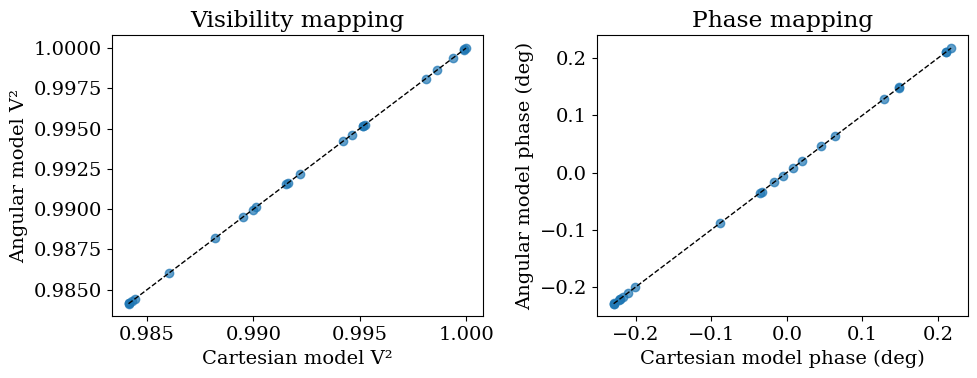

In [14]:
vis_cart = np.asarray(data.to_vis(cvis_true))
vis_ang = np.asarray(data.to_vis(cvis_ang))
phi_cart = np.asarray(data.to_phases(cvis_true))
phi_ang = np.asarray(data.to_phases(cvis_ang))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.scatter(vis_cart, vis_ang, alpha=0.7)
line_v = np.linspace(min(vis_cart.min(), vis_ang.min()), max(vis_cart.max(), vis_ang.max()), 100)
ax1.plot(line_v, line_v, "k--", lw=1)
ax1.set_xlabel("Cartesian model V²")
ax1.set_ylabel("Angular model V²")
ax1.set_title("Visibility mapping")

ax2.scatter(phi_cart, phi_ang, alpha=0.7)
line_p = np.linspace(min(phi_cart.min(), phi_ang.min()), max(phi_cart.max(), phi_ang.max()), 100)
ax2.plot(line_p, line_p, "k--", lw=1)
ax2.set_xlabel("Cartesian model phase (deg)")
ax2.set_ylabel("Angular model phase (deg)")
ax2.set_title("Phase mapping")

plt.tight_layout()
plt.show()

## Likelihood wiring from `OIData` + model class

`loglike(values, params, data_obj, model_class)` zips parameter names to values, instantiates `model_class(**param_dict)`, evaluates `data_obj.model(...)`, then compares to flattened data with Gaussian errors.

In [ ]:
params_cart = ["dra", "ddec", "flux"]
vals_cart = [dra, ddec, flux]
ll_cart = float(loglike(vals_cart, params_cart, data, BinaryModelCartesian))

params_ang = ["sep", "pa", "contrast"]
vals_ang = [sep, pa, contrast]
ll_ang = float(loglike(vals_ang, params_ang, data, BinaryModelAngular))

ll_cart_perturbed = float(
    loglike([dra + 20.0, ddec - 20.0, flux * 1.6], params_cart, data, BinaryModelCartesian)
)

{
    "ll_cart_true": ll_cart,
    "ll_ang_equivalent": ll_ang,
    "ll_cart_perturbed": ll_cart_perturbed,
    "true_beats_perturbed": bool(ll_cart > ll_cart_perturbed),
}

{'ll_cart_true': -14.96725845336914,
 'll_ang_equivalent': -14.967044830322266,
 'll_cart_perturbed': -854.9948120117188,
 'true_beats_perturbed': True}

This gives a practical under-the-hood view: model classes define parameter syntax and complex visibilities, `OIData` defines observable conventions and flattening, and `loglike` stitches both pieces together for inference workflows.